In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random
import scipy
import functools

In [2]:
def ODE_system_solver(f, y0, t0, final_t, step = 1e-4):

    ts = np.arange(t0, final_t, step)
    ys = np.empty((len(ts), len(y0)), dtype=np.float32)
    ys[0] = y0

    for i, t in enumerate(ts[:-1]):
        ys[i + 1] = ys[i] + f(t, ys[i]) * step

    return ts, ys

In [3]:
class CubicSplineTorch:
    def __init__(self, xs, ys):
        xs = np.asarray(xs, dtype=float).reshape(-1)
        ys = np.asarray(ys, dtype=float).reshape(-1)

        cs = scipy.interpolate.CubicSpline(xs, ys)

        self.xs = torch.tensor(cs.x, dtype=torch.float32)
        # cs.c shape: (4, intervals)
        # order: c0*(x-xi)^3 + c1*(x-xi)^2 + c2*(x-xi) + c3
        self.coeffs = torch.tensor(cs.c.T, dtype=torch.float32)

    def __call__(self, x):
        x = x.reshape(-1)

        idx = torch.searchsorted(self.xs, x) - 1
        idx = idx.clamp(0, len(self.xs) - 2)

        x0 = self.xs[idx]
        dx = x - x0

        c = self.coeffs[idx]  # (N, 4)

        # Horner scheme
        y = ((c[:, 0]*dx + c[:, 1])*dx + c[:, 2])*dx + c[:, 3]

        return y.reshape((-1, 1))

In [4]:
class PDE:

    def __init__(self, u0):
        self.S_inicial = u0(torch.tensor([[0.0, 0.0]]))[0, 0]
        self.S_left = 0.9
        self.u0 = u0

        self.mu_w = 1e-3
        self.mu_g = 1e-5
        self.S_wc = 0.2
        self.S_gr = 0.1


        self.inflection_s = self.get_inflection_point()
        Ss = np.linspace(0.0, 1.0, 100)
        Ss_sigma = [self.get_sigma(S).item() for S in Ss]
        self.f_tilde_prime = CubicSplineTorch(Ss, Ss_sigma)

        
        self.s_star = self.get_s_star(self.S_inicial, self.inflection_s, self.S_left)
        self.sigma = self.get_sigma(self.S_inicial)
        print(f"S_star: {self.s_star}, sigma: {self.sigma}")

    def get_inflection_point(self):
        def obj(x):
            x = torch.as_tensor(x, dtype=torch.float32).requires_grad_(True)
            dy = torch.autograd.grad(self.f(x), x, create_graph=True)[0]
            return torch.autograd.grad(dy, x)[0].item()

        return scipy.optimize.brentq(obj, 0.0, self.S_left)
    
    def get_s_star(self, S_inicial, min_S, max_S):
        def obj(S):
            S_tensor = torch.tensor(S)
            return self.f_prime(S_tensor) - (self.f(S_inicial) - self.f(S_tensor)) / (S_inicial - S_tensor)

        return scipy.optimize.brentq(functools.partial(obj), min_S, max_S)

    def get_sigma(self, S_inicial):
        if S_inicial >= self.inflection_s:
            return self.f_prime(torch.as_tensor(S_inicial))
            
        S_star = self.get_s_star(S_inicial, self.inflection_s, self.S_left)
        return (self.f(S_inicial) - self.f(S_star)) / (S_inicial - S_star)
        

    def k_rw(self, S):
        return ((S - self.S_wc) / (1 - self.S_wc - self.S_gr)) ** 4
    
    def k_rg(self, S):
        return ((1 - S - self.S_gr) / (1 - self.S_wc - self.S_gr)) ** 2
    
    def f(self, S):
        lambda_w = self.k_rw(S) / self.mu_w
        lambda_g = self.k_rg(S) / self.mu_g
        return lambda_w / (lambda_w + lambda_g)
    
    def rhs(self, t, y, dx = 0.01):
        F = np.empty(y.shape[0] + 1, dtype=np.float32)
        F[0] = self.f(self.S_left)
        F[1:] = self.f(y)
    
        return -(F[1:] - F[:-1]) / dx

    def f_prime(self, S):
        if not S.requires_grad:
            S = S.clone().detach().requires_grad_(True)
            
            f_val = self.f(S)
            return torch.autograd.grad(outputs=f_val, inputs=S, grad_outputs=torch.ones_like(f_val))[0]
            
        f_val = self.f(S)
        return torch.autograd.grad(outputs=f_val, inputs=S, grad_outputs=torch.ones_like(f_val), create_graph=True)[0]

    def f_tilde(self, S):
        return torch.where(S < self.s_star, self.f(self.S_inicial) + self.sigma * (S - self.S_inicial), self.f(S))
    

In [48]:
 pde = PDE(lambda x: torch.where(x[:, 1:] >= 0, x[:, 1:] * 0.5, 0.9))

S_star: 0.8973277509200985, sigma: 1.112728476524353


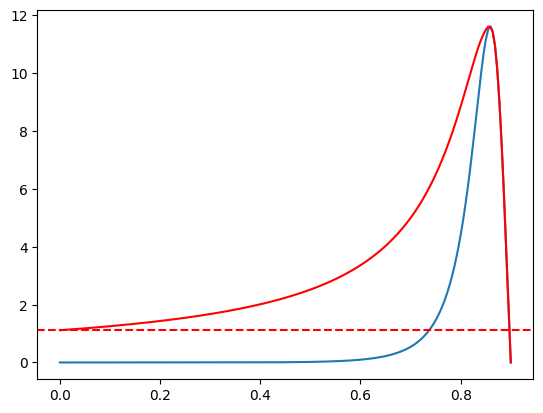

In [49]:
xs_plot = torch.linspace(0.0, 0.9, 200)
plt.plot(xs_plot, pde.f_prime(xs_plot))
plt.plot(xs_plot, pde.f_tilde_prime(xs_plot), color="r")
plt.axhline(y=pde.sigma, color='r', linestyle='--')
plt.show()

In [50]:
L = 1.0
Nx = 100
dx = L / Nx
u = 1e-6
phi = 0.2

dt = 150.0 / (phi / u)
T_max = 150000 / (phi / u)
Nt = np.ceil(T_max / dt)

N_plot = 5000

idxs_t = np.random.randint(low=0, high=Nt, size=N_plot)
idxs_x = np.random.randint(low=0, high=Nx, size=N_plot)

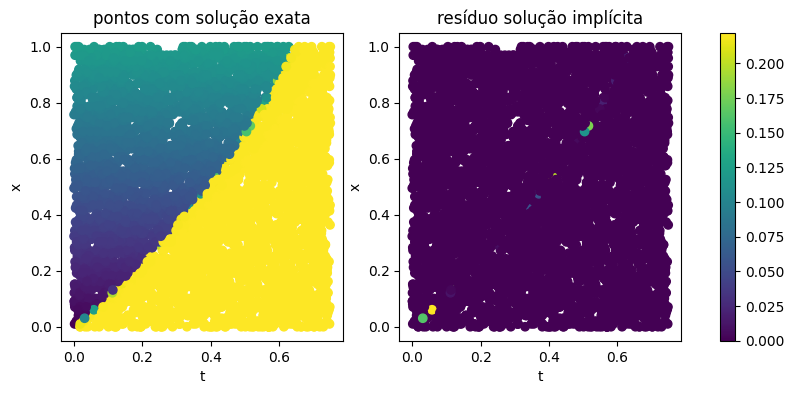

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

xs = torch.linspace(0, L, Nx)
S0 = pde.u0(torch.column_stack((torch.zeros((Nx,)), xs.reshape(-1, 1)))).flatten()

ts, us = ODE_system_solver(functools.partial(pde.rhs, dx=dx), S0.numpy(), 0, T_max, dt)

X_plot = torch.tensor(np.stack((ts[idxs_t], xs[idxs_x]), axis=1))
u_plot = torch.tensor(us[idxs_t, idxs_x])

im_sol = pde.u0(torch.column_stack((X_plot[:, 0], X_plot[:, 1] - pde.f_prime(u_plot) * X_plot[:, 0]))).flatten()
err = (u_plot - im_sol) ** 2

sc = axes[0].scatter(X_plot[:, 0], X_plot[:, 1], c=u_plot, cmap="viridis")
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
axes[0].set_title('pontos com solução exata')

sc = axes[1].scatter(X_plot[:, 0], X_plot[:, 1], c=err, cmap="viridis")
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
axes[1].set_title('resíduo solução implícita')
    
cbar = fig.colorbar(sc, ax=axes, orientation='vertical')

In [52]:
def sample_points(N_colocacao, N_contorno, N_inicial, max_t = T_max):
    X_colocacao = torch.cat([
        (1 - torch.rand(N_colocacao, 1)) * max_t,
        torch.rand(N_colocacao, 1)
    ], dim = 1)

    X_contorno = torch.cat([
        (1 - torch.rand(N_contorno, 1)) * T_max, 
        torch.zeros(N_contorno, 1)
    ], dim = 1)

    X_inicial = torch.cat([
        torch.zeros(N_inicial, 1),
        torch.rand(N_inicial, 1)
    ], dim = 1)

    return X_colocacao, X_contorno, X_inicial

def replace_least_error_points(points, new_points, errors):

    N_todos = points.shape[0]
    N_novos = new_points.shape[0]
    N_resto = N_todos - N_novos
    
    idxs = np.argpartition(-errors.detach().numpy(), N_resto, axis=0).flatten()
    idxs = idxs[:N_resto]

    return torch.cat((points[idxs], new_points), axis=0)    

def resample_ozanski(X_colocacao, X_contorno, X_inicial, model, perc=0.15, perc_boundary=0.1, lambda_1=0.1, max_t = T_max):

    X_todos = torch.cat((X_contorno, X_inicial, X_colocacao), dim=0).requires_grad_(True)
    
    N_colocacao = X_colocacao.shape[0]
    N_contorno = X_contorno.shape[0]
    N_inicial = X_inicial.shape[0]

    y_fake = model(X_todos)
    y_fake_contorno = y_fake[0:N_contorno, :]
    y_fake_inicial = y_fake[N_contorno:N_contorno + N_inicial, :]

    L_f, L_b1, L_b2 = pinn_loss(X_todos, y_fake, X_contorno, y_fake_contorno, X_inicial, y_fake_inicial, make_reduction=False)

    loss_contorno = L_f[0:N_contorno, :] + lambda_1 * L_b2
    loss_inicial = L_f[N_contorno:N_contorno + N_inicial, :] + lambda_1 * L_b1
    loss_colocacao = L_f[N_contorno + N_inicial:, :]

    X_novos_colocacao, X_novos_contorno, X_novos_inicial = sample_points(int(N_colocacao * perc), int(N_contorno * perc_boundary), int(N_inicial * perc_boundary), max_t)

    X_final_colocacao = replace_least_error_points(X_colocacao, X_novos_colocacao, loss_colocacao)
    X_final_contorno = replace_least_error_points(X_contorno, X_novos_contorno, loss_contorno)
    X_final_inicial = replace_least_error_points(X_inicial, X_novos_inicial, loss_inicial)

    return X_final_colocacao, X_final_contorno, X_final_inicial


In [10]:
def pinn_loss(X_batch, y_fake, X_contorno, y_contorno, X_inicial, y_inicial, lambda_1 = 1.0, make_reduction=True):
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]

    f_val = pde.f(y_fake)
    df_dy = torch.autograd.grad(f_val, y_fake, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, 0:1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dy * dy_dx # regra da cadeia
    

    if make_reduction:
        L_f = torch.mean((dy_dt + df_dx) ** 2)
        L_b1 = torch.mean((y_inicial - pde.u0(X_inicial)) ** 2)
        L_b2 = torch.mean((y_contorno - 0.9) ** 2)
    
        return L_f, L_b1, L_b2
    else:
        L_f = (dy_dt + df_dx) ** 2
        L_b1 = (y_inicial - pde.u0(X_inicial)) ** 2
        L_b2 = (y_contorno - 0.9) ** 2
        
        return L_f, L_b1, L_b2

In [53]:
def pde_loss(X_batch, y_fake, lambda_1 = 1.0):
    
    f_val = pde.f(y_fake)
    
    dy_dX = torch.autograd.grad(y_fake, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    df_dX = torch.autograd.grad(f_val, X_batch, grad_outputs=torch.ones_like(y_fake), create_graph=True)[0]
    
    dy_dt = dy_dX[:, 0:1]
    dy_dx = dy_dX[:, 1:]
    df_dx = df_dX[:, 1:]

    return torch.mean((dy_dt + df_dx) ** 2)

In [11]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z)

In [173]:
class PINN(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=32):
        super().__init__()
        self.net_IC = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )

        self.net_BC = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid(),
        )

        self.net_RH = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, input_dim - 1),
        )

    def forward(self, z):
        
        descontinuidade = self.net_RH(z[:, 0:1])
        return torch.where(z[:, 1:] > descontinuidade, self.net_IC(z), self.net_BC(z))

In [174]:
N_colocacao = 15000
N_contorno = 1500
N_inicial = 1500

# pontos usados (escolhidos aleatoriamente a cada passo de treino)
X_colocacao, X_contorno, X_inicial = sample_points(N_colocacao, N_contorno, N_inicial)

batch_size = 2048
batch_contorno = batch_size // 7
batch_inicial = batch_size // 7
batch_colocacao = batch_size - batch_contorno - batch_inicial

PINN_model = PINN(2, 1, 64)

n_iter = 25000
lr = 1e-3
optimizer_IC = optim.Adam(PINN_model.net_IC.parameters(), lr=lr)
optimizer_BC = optim.Adam(PINN_model.net_BC.parameters(), lr=lr)
optimizer_RH = optim.Adam(PINN_model.net_RH.parameters(), lr=1e-4)

# a cada quantas iterações vamos alterar os pontos usados
N_change_points = 75

todas_loss = []

In [175]:
ts_treino = torch.tensor(ts, dtype=torch.float32).reshape(-1, 1).requires_grad_(True)

In [177]:
for it in range(n_iter):

    if it < 2500:
        X_batch_colocacao = X_colocacao[torch.randint(0, N_colocacao, (batch_colocacao,))]
        X_batch_contorno = X_contorno[torch.randint(0, N_contorno, (batch_contorno,))]
        X_batch_inicial = X_inicial[torch.randint(0, N_inicial, (batch_inicial,))]
        
        X_batch_IC = torch.cat((X_batch_inicial, X_batch_colocacao), dim=0).requires_grad_(True)
        X_batch_BC = torch.cat((X_batch_contorno, X_batch_colocacao), dim=0).requires_grad_(True)
    
        y_fake_IC = PINN_model.net_IC(X_batch_IC)
        y_fake_BC = PINN_model.net_BC(X_batch_BC)
    
        L_pde_IC = pde_loss(X_batch_IC, y_fake_IC)
        L_pde_BC = pde_loss(X_batch_BC, y_fake_BC)
    
        L_IC = L_pde_IC + torch.mean((y_fake_IC[:batch_inicial, :] - pde.u0(X_batch_inicial)) ** 2)
        L_BC = L_pde_BC + torch.mean((y_fake_BC[:batch_contorno, :] - 0.9) ** 2)
    
        optimizer_IC.zero_grad()
        L_IC.backward()
        optimizer_IC.step()
    
        optimizer_BC.zero_grad()
        L_BC.backward()
        optimizer_BC.step()
        

    if it > 2500:
        descontinuidade = PINN_model.net_RH(ts_treino)
        pontos_descontinuidade = torch.column_stack((ts_treino, descontinuidade))
        # print(pontos_descontinuidade)
    
        with torch.no_grad():
            u_l = PINN_model.net_IC(pontos_descontinuidade)
            u_r = PINN_model.net_BC(pontos_descontinuidade)
            RH_speed = (pde.f(u_l) - pde.f(u_r)) / (u_l - u_r)
        # print(u_l, u_r)
        speed = torch.autograd.grad(descontinuidade, ts_treino, grad_outputs=torch.ones_like(descontinuidade), create_graph=True)[0]
    
        L_RH = torch.mean((RH_speed - speed) ** 2) + descontinuidade[0] ** 2


        optimizer_RH.zero_grad()
        L_RH.backward()
        optimizer_RH.step()
    
    if (it + 1) % (n_iter // 10) == 0:
        print(f"Iter {it+1}: L_RH={L_RH.item():.10f}")

Iter 2500: L_RH=0.0012115856
Iter 5000: L_RH=0.0003743993
Iter 7500: L_RH=0.0015167125
Iter 10000: L_RH=0.0023683868
Iter 12500: L_RH=0.0027529486
Iter 15000: L_RH=0.0018201087
Iter 17500: L_RH=0.0015055320
Iter 20000: L_RH=0.0006620458
Iter 22500: L_RH=0.0005991294
Iter 25000: L_RH=0.0004008985


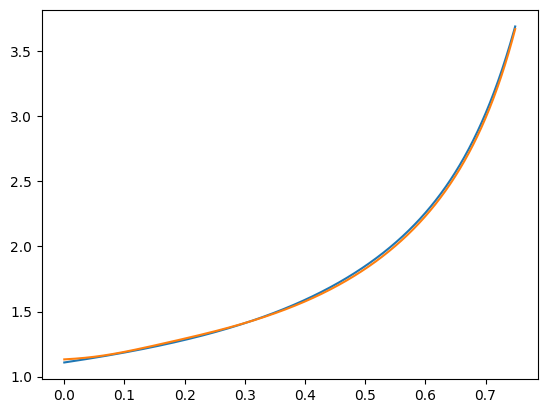

In [178]:
descontinuidade = PINN_model.net_RH(ts_treino)
speed = torch.autograd.grad(descontinuidade, ts_treino, grad_outputs=torch.ones_like(descontinuidade), create_graph=True)[0]

pontos_descontinuidade = torch.column_stack((ts_treino, descontinuidade))
# print(pontos_descontinuidade)

with torch.no_grad():
    u_l = PINN_model.net_IC(pontos_descontinuidade)
    u_r = PINN_model.net_BC(pontos_descontinuidade)
RH_speed = (pde.f(u_l) - pde.f(u_r)) / (u_l - u_r)

plt.plot(ts_treino.detach(), speed.detach())
plt.plot(ts_treino.detach(), RH_speed.detach())
plt.show()

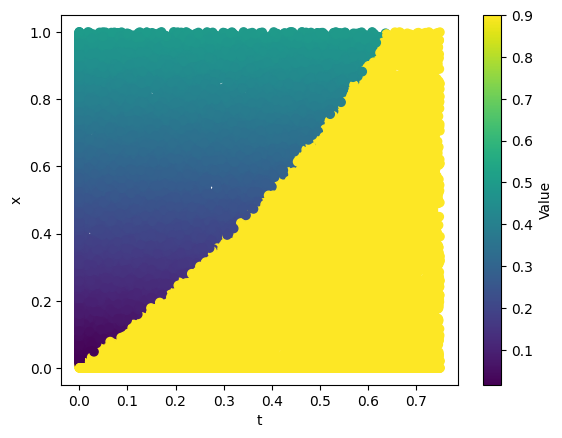

In [179]:
# X_colocacao, X_contorno, X_inicial = sample_points(3400, 300, 300)
x_plot = torch.cat((X_colocacao, X_inicial, X_contorno))

y_pred = PINN_model(x_plot).detach().numpy()
x_plot = x_plot.detach().numpy()

plt.scatter(x_plot[:, 0], x_plot[:, 1:], c=y_pred, cmap="viridis")
plt.xlabel('t')
plt.ylabel('x')
plt.colorbar(label='Value')
plt.show()

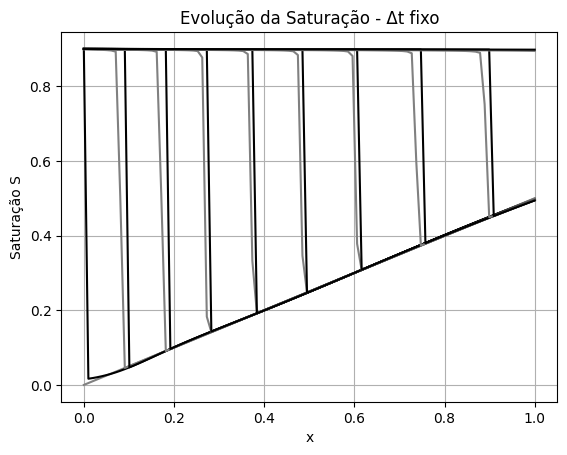

In [180]:
for idx, t in enumerate(ts[::100]):
    X = torch.tensor(np.stack([np.full(xs.shape, t), xs], axis=1), dtype=torch.float32)
    S = PINN_model(X).detach().cpu().numpy()

    plt.plot(xs, us[idx * 100, :], label=f't = {t/3600:.1f} h', color="gray")
    plt.plot(xs, S, label=f't = {t/3600:.1f} h', color="black")

plt.xlabel('x')
plt.ylabel('Saturação S')
plt.title('Evolução da Saturação - Δt fixo')
# plt.legend()
plt.grid(True)
plt.show()